# High Resolution: Atmosphere


In [1]:
import os

import xarray as xr

# import uxarray as ux
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
CESM_output_dir = ""
data_path = ""
case_name = ""
start_date = ""
end_date = ""
grid_file = ""
regridded_output = False

In [3]:
CESM_output_dir = "/glade/derecho/scratch/mcallahan/archive"
case_name = "b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001"
grid_file = "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.T.000101-000212.nc"
grid_file_path = "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries"

In [4]:
def fix_time_dim(dat):
    """CESM2 output sets time as the end of the averaging interval (e.g. January average is midnight on February 1st);
    This function sets the time dimension to the midpoint of the averaging interval.
    Note that CESM3 output sets time to the midpoint already, so this function should not change CESM3 data."""
    if "time" not in dat.dims:
        return dat
    if "bounds" not in dat.time.attrs:
        return dat
    time_bounds_avg = dat[dat.time.attrs["bounds"]].mean("nbnd")
    time_bounds_avg.attrs = dat.time.attrs
    dat = dat.assign_coords({"time": time_bounds_avg})
    return xr.decode_cf(dat)

In [5]:
if regridded_output:
    file_path = f"{CESM_output_dir}/{case_name}/atm/proc/tseries/regrid"
else:
    file_path = f"{CESM_output_dir}/{case_name}/atm/hist"

# T - 3D temperature field

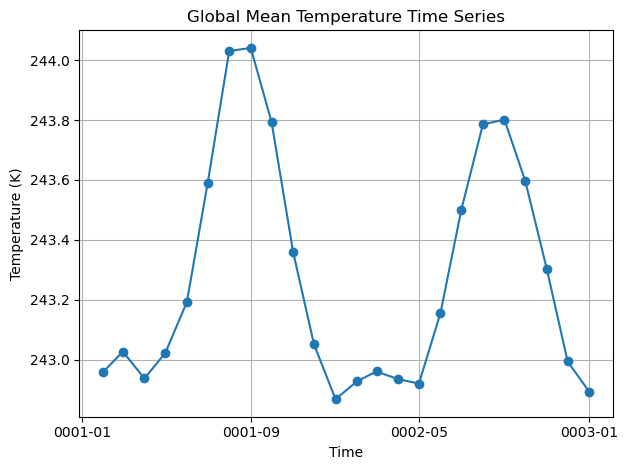

In [6]:
ds = xr.open_mfdataset(
    f"{file_path}/*.cam.h0.*.nc", combine="by_coords", decode_times=True
)

# Choose the temperature variable
T = ds["T"]  # (time, lev, ncol)

# Average over all levels and all columns
T_mean = T.mean(dim=["lev", "ncol"])

# Use just the surface level (e.g., lev[0])
# T_surface = T.isel(lev=0).mean(dim="ncol")

T_mean.plot.line(marker="o")
plt.title("Global Mean Temperature Time Series")
plt.ylabel("Temperature (K)")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

<xarray.Dataset> Size: 2GB
Dimensions:    (lev: 30, ilev: 31, time: 24, nbnd: 2, ncol: 777602)
Coordinates:
  * lev        (lev) float64 240B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev       (ilev) float64 248B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time       (time) object 192B 0001-02-01 00:00:00 ... 0003-01-01 00:00:00
Dimensions without coordinates: nbnd, ncol
Data variables:
    hyam       (lev) float64 240B ...
    hybm       (lev) float64 240B ...
    P0         float64 8B ...
    hyai       (ilev) float64 248B ...
    hybi       (ilev) float64 248B ...
    time_bnds  (time, nbnd) object 384B ...
    PS         (time, ncol) float32 75MB ...
    T          (time, lev, ncol) float32 2GB ...
Attributes:
    np:               4
    ne:               120
    Conventions:      CF-1.0
    source:           CAM
    case:             b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001
    title:            UNSET
    logname:          fredc
    host:          

(array([8.27464000e+05, 3.59045800e+07, 1.02866315e+08, 1.03658721e+08,
        6.30281940e+07, 4.43339860e+07, 5.55472380e+07, 8.05243710e+07,
        7.19383550e+07, 1.24421600e+06]),
 array([171.12416077, 185.57519531, 200.0262146 , 214.47724915,
        228.92828369, 243.37930298, 257.83032227, 272.28137207,
        286.73239136, 301.18341064, 315.63446045]),
 <BarContainer object of 10 artists>)

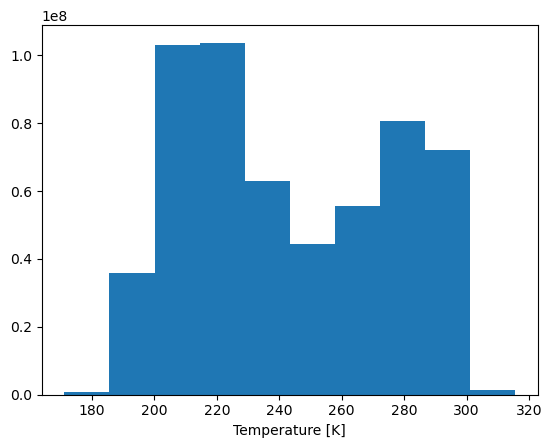

In [7]:
ds = xr.open_dataset(grid_file)

# Check available variables
print(ds)

T = ds["T"]
T.plot()

/glade/work/mcallahan/conda-envs/cupid-analysis/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2139: UserWarning: The following kwargs were not used by contour: 'legend'
  primitive = ax.contourf(x, y, z, **kwargs)


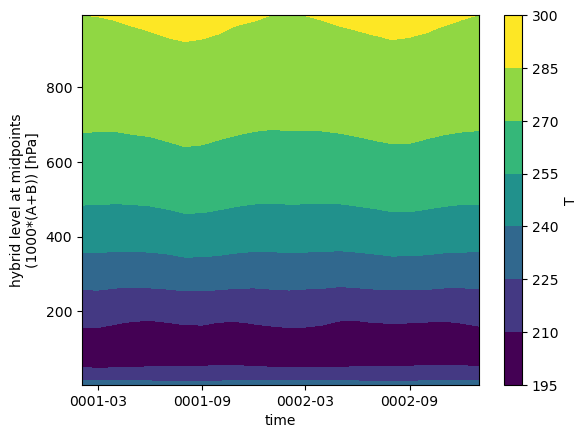

In [8]:
T_mean = T.mean(dim="ncol")  # spatial average
T_mean.plot.contourf(x="time", legend=True)
# plt.title("Mean Temperatrue")
# plt.ylabel("Temperature (K)")

In [ ]:
# def spatial_average(indata, weights=None, spatial_dims=None):
#     """Compute spatial average.

#     Parameters
#     ----------
#     indata : xr.DataArray
#         input data
#     weights : np.ndarray or xr.DataArray, optional
#         the weights to apply, see Notes for default behavior
#     spatial_dims : list, optional
#         list of dimensions to average, see Notes for default behavior

#     Returns
#     -------
#     xr.DataArray
#         weighted average of `indata`

#     Notes
#     -----
#     When `weights` is not provided, tries to find sensible values.
#     If there is a 'lat' dimension, use `cos(lat)`.
#     If there is a 'ncol' dimension, looks for `area` in `indata`.
#     Otherwise, set to equal weights.

#     Makes an attempt to identify the spatial variables when `spatial_dims` is None.
#     Will average over `ncol` if present, and then will check for `lat` and `lon`.
#     When none of those three are found, raise an AdfError.
#     """
#     import warnings

#     if weights is None:
#         #Calculate spatial weights:
#         if 'lat' in indata.coords:
#             weights = np.cos(np.deg2rad(indata.lat))
#             weights.name = "weights"
#         elif 'ncol' in indata.dims:
#             if 'area' in indata:
#                 warnings.warn("area variable being used to generated normalized weights.")
#                 weights = indata['area'] / indata['area'].sum()
#             else:
#                 warnings.warn("\t  We need a way to get area variable. Using equal weights.")
#                 weights = xr.DataArray(1.)
#             weights.name = "weights"
#         else:
#             weights = xr.DataArray(1.)
#             weights.name = "weights"
#             warnings.warn("Un-recognized spatial dimensions: using equal weights for all grid points.")
#         #End if
#     #End if

#     #Apply weights to input data:
#     weighted = indata.weighted(weights)

#     # we want to average over all non-time dimensions
#     if spatial_dims is None:
#         if 'ncol' in indata.dims:
#             spatial_dims = ['ncol']
#         else:
#             spatial_dims = [dimname for dimname in indata.dims if (('lat' in dimname.lower()) or ('lon' in dimname.lower()))]

#     if not spatial_dims:
#         #Scripts using this function likely expect the horizontal dimensions
#         #to be removed via the application of the mean. So in order to avoid
#         #possibly unexpected behavior due to arrays being incorrectly dimensioned
#         #(which could be difficult to debug) the ADF should die here:
#         emsg = "spatial_average: No spatial dimensions were identified,"
#         emsg += " so can not perform average."
#         raise AdfError(emsg)

#     return weighted.mean(dim=spatial_dims, keep_attrs=True)

/glade/derecho/scratch/mcallahan/tmp/ipykernel_84037/2088255292.py:41: UserWarning: 	  We need a way to get area variable. Using equal weights.
  warnings.warn("\t  We need a way to get area variable. Using equal weights.")


Text(0, 0.5, 'Temperature (K)')

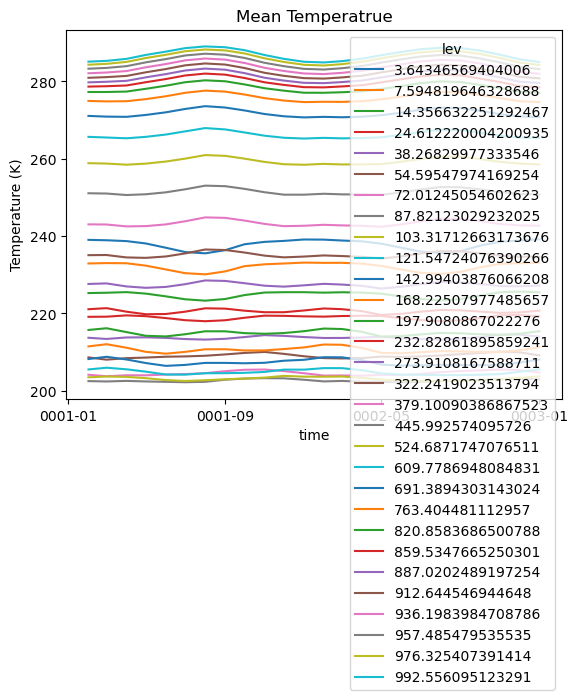

In [ ]:
# T_avg = spatial_average(T, spatial_dims='ncol')
# #T_mean = T.mean(dim='ncol')
# p = T_avg.plot.line(x='time',
#                  hue= 'lev',)
# plt.title("Mean Temperatrue")
# plt.ylabel("Temperature (K)")

/glade/work/mcallahan/conda-envs/cupid-analysis/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2139: UserWarning: The following kwargs were not used by contour: 'legend'
  primitive = ax.contourf(x, y, z, **kwargs)


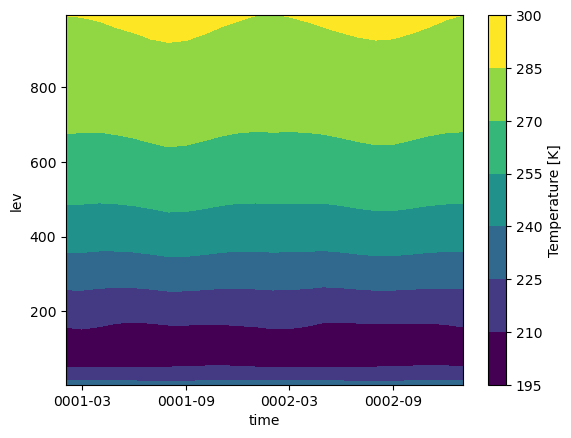

In [ ]:
# T_avg.plot.contourf(x='time', legend = True)

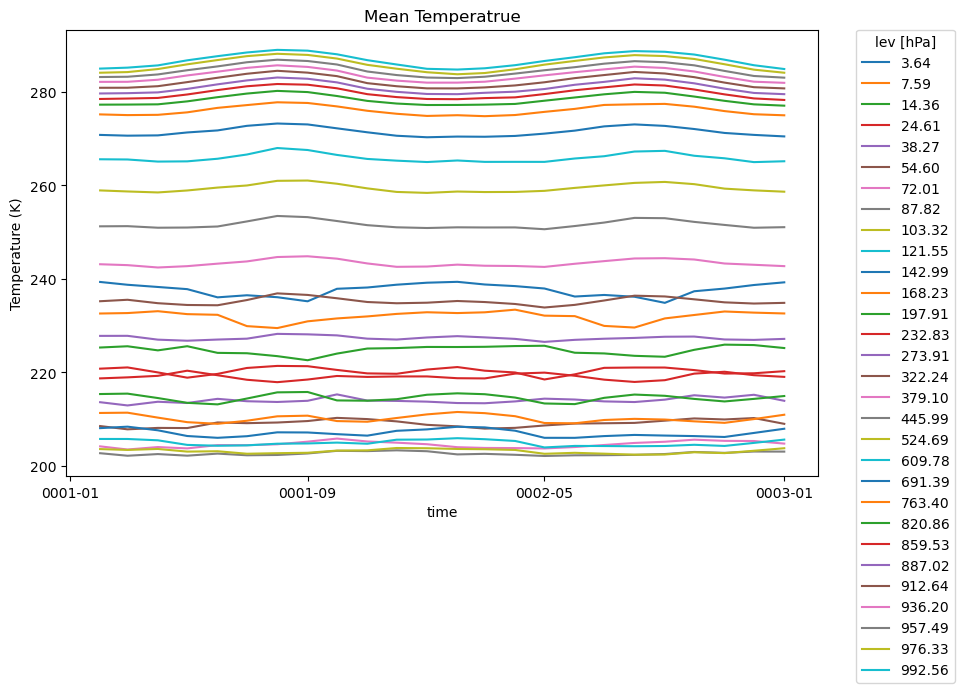

In [12]:
# grid_file_path= '/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries'
# ds_T = xr.open_dataset(f"{grid_file_path}/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.T.000101-000212.nc")


T_mean = T.mean(dim="ncol")
p = T_mean.plot.line(x="time", hue="lev", aspect=1.5, size=6.5)
plt.title("Mean Temperatrue")
plt.ylabel("Temperature (K)")

lev_vals = T_mean["lev"].values
lev_labels = [f"{lev:.2f}" for lev in lev_vals]
plt.legend(
    labels=lev_labels,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
    title="lev [hPa]",
)

plt.tight_layout()  # keeps layout clean
plt.show()

In [13]:
data = T.sel(time="0001-06-01")
ds_full = xr.open_dataset(
    "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/hist/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.0001-06.nc"
)

print(ds_full.coords)
ds_full

Coordinates:
  * lev      (lev) float64 240B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev     (ilev) float64 248B 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time     (time) object 8B 0001-07-01 00:00:00


<xarray.Dataset> Size: 5GB
Dimensions:        (lev: 30, ilev: 31, time: 1, ncol: 777602, nbnd: 2)
Coordinates:
  * lev            (lev) float64 240B 3.643 7.595 14.36 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 248B 2.255 5.032 10.16 ... 967.5 985.1 1e+03
  * time           (time) object 8B 0001-07-01 00:00:00
Dimensions without coordinates: ncol, nbnd
Data variables: (12/173)
    hyam           (lev) float64 240B ...
    hybm           (lev) float64 240B ...
    P0             float64 8B ...
    hyai           (ilev) float64 248B ...
    hybi           (ilev) float64 248B ...
    date           (time) int32 4B ...
    ...             ...
    pom_a1_SRF     (time, ncol) float32 3MB ...
    so4_a1_SRF     (time, ncol) float32 3MB ...
    so4_a2_SRF     (time, ncol) float32 3MB ...
    so4_a3_SRF     (time, ncol) float32 3MB ...
    soa_a1_SRF     (time, ncol) float32 3MB ...
    soa_a2_SRF     (time, ncol) float32 3MB ...
Attributes:
    np:               4
    ne:               120
    Conventions:      CF-1.0
    source:           CAM
    case:             b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001
    title:            UNSET
    logname:          fredc
    host:             derecho6
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     B.E.13.B1850C5.ne120_t12.sehires38.003.sunway_02.cam.i....
    topography_file:  /glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/to...

# TREFHT - Temperature 2m above surface

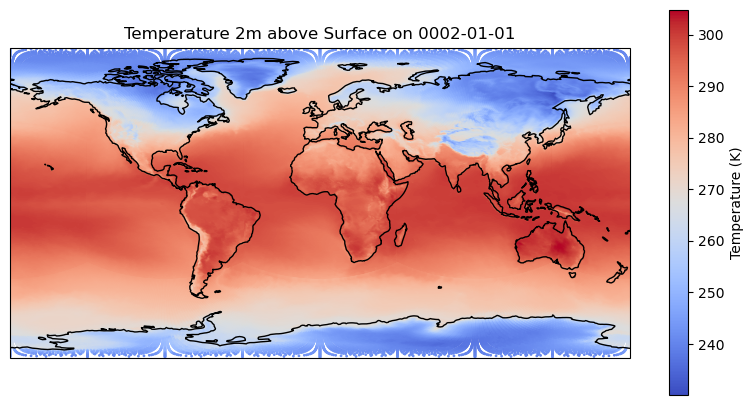

In [14]:
grid_file_TREFHT = "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.TREFHT.000101-000212.nc"
TREFHT_ds = xr.open_dataset(grid_file_TREFHT)
data_TREFHT = TREFHT_ds["TREFHT"].sel(time="0002-01-01")

ds_full = xr.open_dataset(
    "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/hist/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.0002-01.nc"
)
lon = ds_full["lon"]
lat = ds_full["lat"]

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

sc = ax.scatter(
    lon, lat, c=data_TREFHT, s=1, cmap="coolwarm", transform=ccrs.PlateCarree()
)
plt.colorbar(sc, label="Temperature (K)")
ax.coastlines()
ax.set_title("Temperature 2m above Surface on 0002-01-01")
plt.show()

Text(0, 0.5, 'Temperature (K)')

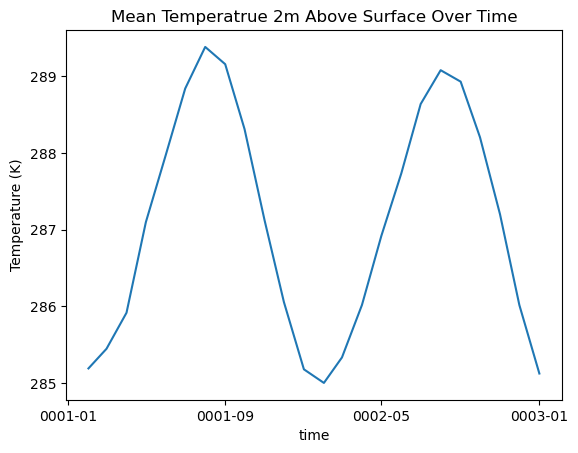

In [ ]:
grid_file_path = "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries"
ds_TREFHT = xr.open_dataset(
    f"{grid_file_path}/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.TREFHT.000101-000212.nc"
)

TREFHT = ds_TREFHT["TREFHT"]
# TREFHT.plot()

TREFHT_mean = TREFHT.mean(dim="ncol")
TREFHT_mean.plot.line(x="time")
plt.title("Mean Temperatrue 2m Above Surface Over Time")
plt.ylabel("Temperature (K)")

# PRECL - Large-scale (stable) precipitation rate (liq + ice)

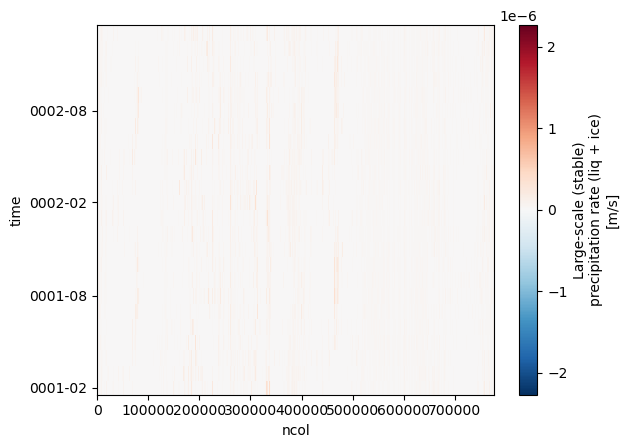

In [16]:
PRECL_grid_file = "/glade/derecho/scratch/mcallahan/archive/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001/atm/proc/tseries/b.e13.B1850C5.ne120_t12.cesm-ihesp-hires1.0.46.HOSING.001.cam.h0.PRECL.000101-000212.nc"
PRECL_ds = xr.open_dataset(PRECL_grid_file)

PRECL = PRECL_ds["PRECL"]
PRECL.plot()

Text(0, 0.5, 'Precipitation Rate (m/s)')

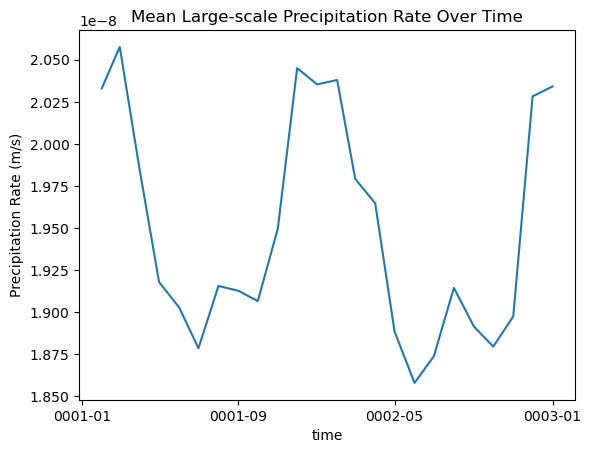

In [ ]:
PRECL_mean = PRECL.mean(dim="ncol")
PRECL_mean.plot.line(x="time")
plt.title("Mean Large-scale Precipitation Rate Over Time")
plt.ylabel("Precipitation Rate (m/s)")